# 1. Setup

In [1]:
# Loading environment variables from .env file
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")  
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")  
os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")  

# 2. Basics

In [2]:
# Creating a basic agent
from langchain.agents import create_agent

agent = create_agent(
    model="claude-sonnet-4-6",
    tools=[],
    system_prompt="You are a helpful assistant."
)

d:\Artificial Intelligence\Notes\7) GenAI\genaiEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


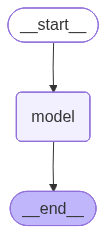

In [3]:
agent

The above setup doesnt have tools as it has not been defined. Now lets define a tool and then define the agent with access to the tool

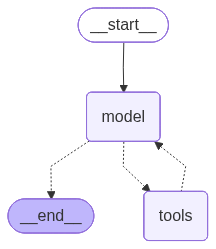

In [4]:
def get_weather(city:str) -> str:
    """Returns the current weather for a given city."""
    return f"The current weather in {city} is sunny with a high of 25°C."

agent = create_agent(
    model="claude-sonnet-4-6",
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)

agent

In [5]:
# Running the agent with a query
agent.invoke({"messages":[{
    "role":"user",
    "content": "What is the weather in Buffalo, NY USA?"
}]})

{'messages': [HumanMessage(content='What is the weather in Buffalo, NY USA?', additional_kwargs={}, response_metadata={}, id='2df3ea84-0682-4a4a-9601-5e8940b4669b'),
  AIMessage(content=[{'id': 'toolu_01JYWDNbux2TAuEtEwD9VXFp', 'input': {'city': 'Buffalo, NY USA'}, 'name': 'get_weather', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_01W4r1KVKDxZC9TZLLbF1UAM', 'model': 'claude-sonnet-4-6', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 577, 'output_tokens': 57, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'global'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019db6d0-931c-7550-8679-6d35640a857d-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Buffalo, NY USA'}, 'id'

In the above cell, to invoke the agent via `create_agent`, the message is passed as dictionary with role as `user` as to indicate the query from user and the `content` which actually contains the user query.

In [6]:
response = agent.invoke({"messages":[{
    "role":"user",
    "content": "What is the weather in Buffalo, NY USA?"
}]})

response["messages"]

[HumanMessage(content='What is the weather in Buffalo, NY USA?', additional_kwargs={}, response_metadata={}, id='4cc10b04-cbf6-46c7-bc5b-0beb7c7b5969'),
 AIMessage(content=[{'id': 'toolu_01EkneA5fFMTWK2UcewfhkLD', 'input': {'city': 'Buffalo, NY USA'}, 'name': 'get_weather', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_01L5NXpx3JTHMkCNPbMvT1yf', 'model': 'claude-sonnet-4-6', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 577, 'output_tokens': 57, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'global'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019db6d0-a0cb-7481-855f-c634185a7758-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Buffalo, NY USA'}, 'id': 'toolu_01Ekn

In [7]:
response["messages"][-1]

AIMessage(content='The current weather in **Buffalo, NY USA** is **sunny** with a high of **25°C (77°F)**. It sounds like a nice day! ☀️', additional_kwargs={}, response_metadata={'id': 'msg_015nrCnrGVvQs9cJUCEh6Z5t', 'model': 'claude-sonnet-4-6', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 664, 'output_tokens': 42, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'global'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019db6d0-a62f-7a32-905a-9a1ebfbae760-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 664, 'output_tokens': 42, 'total_tokens': 706, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}})

In [8]:
response["messages"][-1].content

'The current weather in **Buffalo, NY USA** is **sunny** with a high of **25°C (77°F)**. It sounds like a nice day! ☀️'

In [9]:
# Taking a look at langchain versions
import langchain
langchain.__version__

'1.2.7'

# 3. Model Integrations with Claude, Gemini and GROQ

In [10]:
# Loading simple chat models
from langchain.chat_models import init_chat_model

model = init_chat_model("claude-sonnet-4-6")
model

ChatAnthropic(profile={}, model='claude-sonnet-4-6', max_tokens=4096, anthropic_api_url='https://api.anthropic.com', anthropic_api_key=SecretStr('**********'), model_kwargs={})

In [11]:
# Invoking the model
response = model.invoke("Hello how are you?")
response

AIMessage(content="Hello! I'm doing well, thanks for asking. How are you doing today? Is there something I can help you with? 😊", additional_kwargs={}, response_metadata={'id': 'msg_01B7fwZQxHpZQ7iXrTeQkbHH', 'model': 'claude-sonnet-4-6', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 12, 'output_tokens': 32, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'global'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019db6d0-ae48-7273-806c-ab821de21d1a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 32, 'total_tokens': 44, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}})

In [12]:
response.content

"Hello! I'm doing well, thanks for asking. How are you doing today? Is there something I can help you with? 😊"

In [13]:
# Calling Google Gemini Model

from langchain.chat_models import init_chat_model

# Compared to Google ADK the only extra step is to add google_genai: to the model name
gemini_model = init_chat_model("google_genai:gemini-2.5-flash-lite")

response = gemini_model.invoke("How are parrots able to talk?")
response

AIMessage(content='Parrots are able to "talk" through a fascinating combination of **specialized anatomy, advanced vocal learning abilities, and cognitive skills.** It\'s important to understand that they don\'t "talk" in the way humans do, with understanding of grammar, syntax, or abstract meaning. Instead, they are remarkable imitators and can associate sounds with specific contexts.\n\nHere\'s a breakdown of the key factors:\n\n**1. Specialized Vocal Anatomy:**\n\n*   **Syrinx:** This is the most crucial anatomical feature. Unlike humans who have a larynx (voice box) in their throat, birds have a syrinx located at the base of their trachea where it branches into the lungs. The syrinx is a more complex and flexible sound-producing organ.\n    *   **Muscles:** The syrinx has several muscles that can finely control the tension of membranes within it. This allows parrots to produce a wide range of sounds, from whistles and clicks to complex squawks and even human-like speech.\n    *   *

In [14]:
response.content

'Parrots are able to "talk" through a fascinating combination of **specialized anatomy, advanced vocal learning abilities, and cognitive skills.** It\'s important to understand that they don\'t "talk" in the way humans do, with understanding of grammar, syntax, or abstract meaning. Instead, they are remarkable imitators and can associate sounds with specific contexts.\n\nHere\'s a breakdown of the key factors:\n\n**1. Specialized Vocal Anatomy:**\n\n*   **Syrinx:** This is the most crucial anatomical feature. Unlike humans who have a larynx (voice box) in their throat, birds have a syrinx located at the base of their trachea where it branches into the lungs. The syrinx is a more complex and flexible sound-producing organ.\n    *   **Muscles:** The syrinx has several muscles that can finely control the tension of membranes within it. This allows parrots to produce a wide range of sounds, from whistles and clicks to complex squawks and even human-like speech.\n    *   **Airflow Control:*

In [15]:
# Same task can also be accomplished by using langchain anthropic 
from langchain_anthropic import ChatAnthropic

anthropic_model = ChatAnthropic(model="claude-sonnet-4-6")

response = anthropic_model.invoke("How are parrots able to talk?")
response

AIMessage(content='Parrots are able to produce human-like speech through a combination of physical and cognitive abilities:\n\n## Physical Anatomy\n- Parrots have a **syrinx** (the avian vocal organ) that is highly flexible and capable of producing a wide range of sounds\n- Unlike most birds, parrots also use their **tongue and beak** to shape sounds, similar to how humans use lips and tongue\n- Their vocal tract can be manipulated to mimic different frequencies and tones\n\n## Brain and Learning\n- Parrots have a **well-developed brain region** for vocal learning, sometimes called the "song system"\n- They are **vocal learners**, meaning they can imitate sounds they hear, which is relatively rare in the animal kingdom\n- They have strong **auditory processing** abilities that help them accurately hear and reproduce sounds\n\n## Social Nature\n- In the wild, parrots use vocalizations to **bond with their flock**\n- This social drive makes them motivated to mimic sounds in their environ

In [16]:
# Now same task for gemini model
from langchain_google_genai import ChatGoogleGenerativeAI

gemini_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

response = gemini_model.invoke("How are parrots able to talk?")
response

AIMessage(content='Parrots are able to "talk" through a remarkable combination of specialized anatomy and learned behavior. It\'s important to understand that they don\'t "talk" in the way humans do, with genuine comprehension and intent behind every word. Instead, they are highly skilled vocal mimics.\n\nHere\'s a breakdown of how they achieve this:\n\n**1. Specialized Vocal Anatomy:**\n\n*   **Syrinx:** This is the key organ. Unlike humans who have a larynx in their throat, birds have a syrinx located at the base of the trachea, where it splits into the two bronchi. The syrinx is a complex structure with muscles, membranes, and cartilaginous rings.\n    *   **Dual Control:** The syrinx has two independent sides, allowing parrots to produce two different sounds simultaneously. This contributes to their ability to create complex and varied vocalizations.\n    *   **Fine Muscle Control:** Parrots possess highly developed muscles within their syrinx. These muscles allow them to precisely

## GROQ Model Integrations

In [17]:
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:qwen/qwen3-32b")

response = model.invoke("Why do parrots talk?")
response

AIMessage(content='<think>\nOkay, so the user is asking why parrots talk. Let me start by recalling what I know about parrots. Parrots are known for their ability to mimic human speech, right? But why do they do that? Maybe it\'s related to their social behavior. I remember reading that parrots are highly social animals. In the wild, they communicate with each other to stay in contact with their flock, find mates, or warn about predators. So, maybe mimicking human speech is an extension of that social behavior.\n\nI also think about how parrots have a specialized vocal organ called the syrinx, which is different from the human larynx. This allows them to produce a wide range of sounds. But how does that relate to talking? Maybe their ability to mimic is just a natural extension of their vocal capabilities. However, not all parrots talk the same way. Some species are better at it than others. For example, African Grey Parrots are famous for their talking ability, while others like Cocka

In [18]:
response.content

'<think>\nOkay, so the user is asking why parrots talk. Let me start by recalling what I know about parrots. Parrots are known for their ability to mimic human speech, right? But why do they do that? Maybe it\'s related to their social behavior. I remember reading that parrots are highly social animals. In the wild, they communicate with each other to stay in contact with their flock, find mates, or warn about predators. So, maybe mimicking human speech is an extension of that social behavior.\n\nI also think about how parrots have a specialized vocal organ called the syrinx, which is different from the human larynx. This allows them to produce a wide range of sounds. But how does that relate to talking? Maybe their ability to mimic is just a natural extension of their vocal capabilities. However, not all parrots talk the same way. Some species are better at it than others. For example, African Grey Parrots are famous for their talking ability, while others like Cockatiels might not be

In [19]:
# using langchain groq
from langchain_groq import ChatGroq

groq_model = ChatGroq(model="qwen/qwen3-32b")

response = groq_model.invoke("Why do parrots talk?")
response.content

'<think>\nOkay, so I need to figure out why parrots talk. Hmm, let\'s start by thinking about what I know about parrots. I know they\'re birds, and some species like parakeets or macaws can mimic human speech. But why do they do that? Is it just for fun, or is there a biological reason?\n\nMaybe I should start by considering their natural behavior. In the wild, parrots live in social groups, right? So maybe talking is a way for them to communicate with each other. But in the wild, do they actually use human-like speech? Probably not. They must have their own calls and sounds to interact. But when they\'re around humans, they pick up our words. So maybe talking is a learned behavior to interact with humans.\n\nI\'ve heard that parrots have a special part of their brain called the syrinx, which allows them to produce a wide range of sounds. Their vocal cords might be more flexible than other birds. So maybe their anatomy makes it easier for them to mimic sounds. That could be a reason wh

# 4. Streaming and Batch

## Streaming

Most models can stream their output content while its being generated. By displaying the output progressively, streaming significantly improves user experience, particularly for longer responses. Calling `stream()` returns an iterator that yields output chunks as they are produced. A loop can be used to process each chunk in real-time:

In [20]:
# With invoke it takes time and only generates the output once the model is done with the users query.
from langchain.chat_models import init_chat_model

gemini_model = init_chat_model("google_genai:gemini-2.5-flash-lite")

response = gemini_model.invoke("Write a 700 words paragraph on Reinforcement Learning.")
response.content

'Reinforcement Learning (RL) stands as a powerful and increasingly prevalent paradigm within machine learning, distinguished by its focus on how an agent learns to make sequences of decisions in an environment to maximize a cumulative reward signal. Unlike supervised learning, which relies on labeled datasets, or unsupervised learning, which seeks patterns in unlabeled data, RL operates on a trial-and-error basis. The core of RL involves an **agent** interacting with an **environment**. At each discrete time step, the agent observes the current **state** of the environment, takes an **action** based on its current policy, and receives a **reward** (which can be positive, negative, or zero) and transitions to a new state. The ultimate goal of the agent is to learn a **policy**, which is essentially a strategy that maps states to actions, such that the sum of future rewards, often discounted by a factor to prioritize immediate rewards, is maximized.\n\nThe fundamental challenge in RL is 

In [21]:
# Streaming is all about getting the output as it is being generated by the model. This allows for much faster response times and a more interactive experience for the user.
for chunk in gemini_model.stream("Write a 700 words paragraph on Reinforcement Learning."):
    print(chunk.text)

Rein
forcement learning (RL) stands as a captivating and powerful paradigm within machine learning, fundamentally
 differing from its supervised and unsupervised counterparts by focusing on learning through interaction and reward. Instead of being explicitly told what to do or what patterns to find, an RL agent learns by taking actions in an environment and receiving feedback in the form of rewards or penalties.
 This trial-and-error approach, inspired by behavioral psychology, allows agents to discover optimal strategies for achieving long-term goals in complex and dynamic situations. At its core, the RL framework involves an **agent** that interacts with an **environment**. The agent perceives
 the environment's current **state**, chooses an **action** based on its current policy, and transitions to a new state. This transition is accompanied by a **reward** signal, which can be positive (encouraging the action) or negative (disc
ouraging it). The ultimate objective of the agent is t

In [22]:
for chunk in gemini_model.stream("Why do parrots have colorful feathers?"):
    print(chunk.text, end="|", flush=True)

Parrots have| colorful feathers for a variety of reasons, and it's a fascinating interplay of **|evolutionary pressures** and **biological functions**. Here are the main explanations:

**1. Communication and Social Signaling:**

* **Mate Attraction:** This is a primary driver of vibrant coloration in many species. Bright, well-maintained plumage| can signal a parrot's health, vitality, and genetic quality to potential mates. A parrot with dull or damaged feathers might be seen as less desirable.
* **Species Recognition:** Different parrot species often have distinct color patterns, which helps them| identify and interact with their own kind. This is crucial for finding mates, forming flocks, and avoiding interbreeding with other species.
* **Social Status and Dominance:** In some parrot societies, certain colors or patterns might indicate dominance or| social rank within a flock. This can influence access to resources like food and nesting sites.
* **Alarm Signals:** While not as commo

## Batch

Batching is a collection of independent requests to a model that can significantly improve performance and reduce costs, as the processing can be done in parallel.

In [23]:
from langchain.chat_models import init_chat_model

gemini_model = init_chat_model("google_genai:gemini-2.5-flash-lite")

responses = gemini_model.batch(["Why do parrots have colorful feathers?", 
                                "How do airplanes fly?", 
                                "What is reinforcement learning?"],
                                config={
                                    'max_concurrency':5, # Limits to 5 parallel requests
                                })

for response in responses:
    print(response)

content="Parrots have colorful feathers for a variety of fascinating reasons, primarily revolving around **survival and reproduction**. It's a complex interplay of factors, but here are the main drivers:\n\n**1. Communication and Social Signaling:**\n\n* **Mate Attraction:** This is arguably the most significant reason. Bright, vibrant plumage can signal a parrot's health, vitality, and genetic quality to potential mates. A parrot with stunning colors is likely well-nourished and free from parasites, making it a desirable partner. Think of it like a peacock's elaborate tail.\n* **Species Recognition:** In a diverse world with many similar-looking birds, distinct color patterns help parrots identify members of their own species. This is crucial for finding mates, forming flocks, and avoiding interbreeding.\n* **Social Status and Dominance:** Within a flock, color can sometimes indicate social rank or dominance. Brighter individuals might be more dominant, while duller ones might be subo

# 5. Tools in LangChain

Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code. Tools are pairings of:
1. A schema, including the name of the tool, a description, and/or argument definitions (often a JSON Schema)
2. A function or coroutine to execute

In [ ]:
# Creating a basic agent
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:qwen/qwen3-32b")

response = model.invoke("Why do parrots talk?")
response

AIMessage(content='<think>\nOkay, so I need to figure out why parrots talk. Let me start by thinking about what I know about parrots. They\'re birds known for mimicking human speech. But why do they do that? Maybe it\'s about communication. I remember reading that parrots are social animals, so maybe talking helps them interact with other parrots or humans. But wait, do wild parrots talk? Probably not as much as pet ones. So maybe it\'s a learned behavior from humans. \n\nI should consider their anatomy. Parrots have a syrinx, which is their voice box, right? How does that work compared to humans? Maybe their vocal cords or syrinx allows them to mimic sounds. But how exactly? Also, some birds like mynas and crows can mimic, but parrots are particularly good. Is there a specific part of their brain responsible for this? I think it\'s related to the forebrain and areas involved in learning and memory.\n\nAnother angle: why would a parrot evolve the ability to mimic human speech? In the w

In [27]:
# Creating a basic tool for the above agent

from langchain.tools import tool

# Use a decorator to turn a function into a tool that can be used by the agent
@tool
def get_weather(location:str) -> str:
    """Returns the current weather for a given location."""
    return f"The current weather in {location} is sunny with a high of 25°C."

# Now that the tool has been created, we need to bind it to the agent defined above
model_with_tools = model.bind_tools([get_weather])

# We can use the above way or directly define the agent with the tool as shown in previous cells. Both will work the same way.

# Now calling the agent with the tool
response = model_with_tools.invoke("What is the weather in Buffalo, NY USA?")
print(response)

for tool_call in response.tool_calls:
    print(f"Tool called: {tool_call["name"]} \n arguments: {tool_call["args"]}")

content='' additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in Buffalo, NY USA. I need to use the get_weather function they provided. Let me check the function parameters. The function requires a location, which is a string. Buffalo, NY USA is the location they mentioned. So I should call get_weather with location set to "Buffalo, NY USA". I need to make sure the JSON is correctly formatted. Let me structure the tool_call with the function name and the arguments. That should do it.\n', 'tool_calls': [{'id': '2brkj0nm0', 'function': {'arguments': '{"location":"Buffalo, NY USA"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 129, 'prompt_tokens': 158, 'total_tokens': 287, 'completion_time': 0.207943479, 'completion_tokens_details': {'reasoning_tokens': 101}, 'prompt_time': 0.010895978, 'prompt_tokens_details': None, 'queue_time': 0.076336759, 'total_time': 0.218839457}, 'model_name': 'qwen/qwen3-32b

## Tool Execution Loops

In [29]:
# 1: The model generates tool calls
messages =[{"role":"user",
    "content":"What is the weather in Buffalo, NY USA?"
}]

ai_msg = model_with_tools.invoke(messages)

messages.append(ai_msg)

# 2: Execute tools and collectn results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with the generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

# 3: Passing the results back to the model for final response generation
final_response = model_with_tools.invoke(messages)
print(final_response.text)

The current weather in Buffalo, NY USA is **sunny** with a high temperature of **25°C**. Let me know if you'd like additional details! ☀️


In [30]:
messages

[{'role': 'user', 'content': 'What is the weather in Buffalo, NY USA?'},
 AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking for the weather in Buffalo, NY USA. Let me check the tools available. There's a function called get_weather that takes a location parameter. The required parameter is location, which should be a string. Buffalo, NY USA is the location they provided. I need to call get_weather with that location. Make sure the arguments are correctly formatted as a JSON object. Let me structure the tool call accordingly.\n", 'tool_calls': [{'id': 'nx0qpta3e', 'function': {'arguments': '{"location":"Buffalo, NY USA"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 158, 'total_tokens': 273, 'completion_time': 0.181453407, 'completion_tokens_details': {'reasoning_tokens': 87}, 'prompt_time': 0.006764536, 'prompt_tokens_details': None, 'queue_time': 0.204722079, 'total_t

# 6. Messages

Messages are the fundamental unit of context for models in LangChain. They represent the input and output of models, carrying both the content and metadata needed to represent the state of conversation when interacting with an LLM. Messages are objects that contain:
- `Role`: Identifies the message type (e.g. system, user)
- `Content`: Represents the actual content of the message (like text, images, audio, documents, etc.)
- `Metadata`: Optional fields such as response information, message IDs and token usage

LangChain provides a standard message type that works across all model providers, ensuring consistent behavior regardless of the model being called.

In [31]:
# Initializing the model
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:qwen/qwen3-32b")  

In [32]:
# Whenever a message is passed via model.invoke its treated as a human message
model.invoke("Tell me about quantum computing.")
# The output is generated by the model and treated as an assistant message.

AIMessage(content="<think>\nOkay, so I need to understand quantum computing. Let me start by recalling what I know from school. I remember that classical computers use bits, which are either 0 or 1. But quantum computers use qubits, which can be 0, 1, or something in between. Wait, is that right? Maybe it's more like superposition? Yeah, quantum superposition allows a qubit to be in a combination of states. So, a qubit isn't just 0 or 1 but can be both simultaneously. That sounds like it could process more information at once, but how does that actually work?\n\nThen there's entanglement. I think that's when two particles are linked, so the state of one affects the other instantly, no matter the distance. How does that play into computing? Maybe entangled qubits can be used to perform operations more efficiently? But I'm not sure how exactly.\n\nAnother term I've heard is quantum gates. Classical computers have logic gates like AND, OR, NOT. Quantum computers must have something simila

## Text Prompt

Text prompts are strings - ideal for straightforward generation tasks where you dont need to retain conversation history.

In [33]:
model.invoke("What is LangChain?")
"""
The above scenario, nothing has been specified to the model, a simple message is passed which is treated as a human message but internally,
its treated as a text prompt.
"""

'\nThe above scenario, nothing has been specified to the model, a simple message is passed which is treated as a human message but internally,\nits treated as a text prompt.\n'

Text Prompts are useful in the following scenarios:
- You have a single standalone request
- You dont need a conversation histoy
- You want to have minimal code complexity

## Messages Prompts

Here we can pass in a list of messages to the model by providing a list of message objects.

Types of Message:
- `System Message`: Tells the model how to behave and provide context for interactions
- `Human message`: Represents user input and interactions with the model
- `AI Message`: Response generated by the model, including text content, tool calls and meta data
- `Tool Message`: Represents the outputs of tool calls

### System Message

A `SystemMessage` represents an initial set of instructions that primes the model's behavior. You can use a system message to set the tone, define the model's role and establish guidelines for responses

### Human Message

A `HumanMessage` represents user input and interactions. They can contain text, images, audio, files and any other amount of multimodal content.


### AI Message

An `AIMessage` represents the output of a model invocation. They can include multimodal data, tool calls and provide specific metadata that you can later access.

### Tool Message

For models that support tool calling, AI messages can contain tool calls. Tool messages are used to pass the results of a single tool execution back to the model.

In [34]:
# Importing Messages
from langchain.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage(content="You are a poetry expert."),
    HumanMessage(content="What a poem about Reinforcement Learning?")
]

response = model.invoke(messages)
response.content

'<think>\nOkay, the user wants a poem about Reinforcement Learning. Let me start by recalling what Reinforcement Learning (RL) is. It\'s a type of machine learning where an agent learns to make decisions by performing actions and receiving rewards or penalties. So, I need to capture that process in poetic form.\n\nFirst, think about the key elements of RL: the agent, environment, actions, rewards, exploration vs. exploitation, policies, and maybe concepts like Q-learning or neural networks. How can I translate these into poetic imagery?\n\nMaybe start with the agent as a traveler or explorer in an unknown land. The environment could be a vast, shifting landscape. The agent\'s trial and error could be portrayed as steps in the dark, learning from each misstep. Rewards might be likened to finding hidden treasures or light in the dark.\n\nI should use metaphors that evoke learning and adaptation. Words like "whispers of reward," "punishment\'s sting," "maps of memory" (for policies), "neu

In [35]:
print(response.content)

<think>
Okay, the user wants a poem about Reinforcement Learning. Let me start by recalling what Reinforcement Learning (RL) is. It's a type of machine learning where an agent learns to make decisions by performing actions and receiving rewards or penalties. So, I need to capture that process in poetic form.

First, think about the key elements of RL: the agent, environment, actions, rewards, exploration vs. exploitation, policies, and maybe concepts like Q-learning or neural networks. How can I translate these into poetic imagery?

Maybe start with the agent as a traveler or explorer in an unknown land. The environment could be a vast, shifting landscape. The agent's trial and error could be portrayed as steps in the dark, learning from each misstep. Rewards might be likened to finding hidden treasures or light in the dark.

I should use metaphors that evoke learning and adaptation. Words like "whispers of reward," "punishment's sting," "maps of memory" (for policies), "neural webs" f

In [36]:
system_msg = SystemMessage("You are a helpful coding assistant.")

messages = [system_msg,
            HumanMessage("How do I create a REST API?")]

response = model.invoke(messages)
print(response.content)

<think>
Okay, the user is asking how to create a REST API. Let me start by recalling what a REST API is. REST stands for Representational State Transfer, and it's a way to design web services that are scalable and stateless. So the user probably wants to build a web service that can handle HTTP requests.

First, I need to outline the steps. They might need to choose a programming language and framework. Since the question is general, maybe I should mention a few popular options like Python with Flask or Django, Node.js with Express, Java with Spring Boot, etc. But maybe I should focus on one to be concise. Python's Flask is a good starting point because it's simple and widely used for tutorials.

Next, the user will need to set up a development environment. They might not have the language installed, so including installation steps would be helpful. For Python, that would be installing Python and pip, then Flask.

Then, the basic structure of the API. They need to know about HTTP metho

In [37]:
#Detailed info to the LLM through System message
from langchain.messages import SystemMessage, HumanMessage

system_msg = SystemMessage("""
You are a senior Python developer with expertise in web frameworks.
Always provide code examples and explain your reasoning.
Be concise but thorough in your explanations.
""")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)
print(response.content)

<think>
Okay, the user is asking how to create a REST API. Let me start by recalling what a REST API is. REST stands for Representational State Transfer, and it's an architectural style for designing networked applications. It uses HTTP methods like GET, POST, PUT, DELETE, etc.

First, I need to choose a framework in Python. The user mentioned being a Python developer, so maybe they're thinking about using Flask or Django. Both are popular for building web applications. Flask is lightweight and has extensions for APIs, while Django comes with more built-in features but might be heavier. Since the question is about REST APIs, maybe Flask with Flask-RESTful or Django REST framework are good options.

I should outline the steps for both, but maybe start with a simple example using Flask. Let me think about the structure. The basic steps would be: install Flask, create a Flask app, define endpoints, handle different HTTP methods, and maybe set up a database if they need to persist data. Bu

In [38]:
# Message Metadata
human_msg = HumanMessage(
    content="Hello!",
    name="alice",  # Optional: identify different users
    id="msg_123",  # Optional: unique identifier for tracing
)

In [39]:
response = model.invoke([human_msg])
print(response.content)

<think>
Okay, the user said 'Hello!'. I should respond in a friendly and welcoming way. Let me make sure to keep it natural and conversational. Maybe add an emoji to keep it light. No need for any complex language here. Just a simple greeting and offer to help.

Wait, maybe I should also consider the context. Since they started with a greeting, they might be testing the waters or looking for a conversation. I should be open to whatever they need. Let me check the tone again. Friendly and approachable. Yeah, that's good. Alright, time to put it all together.
</think>

Hi there! 😊 How can I assist you today?


In [40]:
from langchain.messages import AIMessage, SystemMessage, HumanMessage

# Create an AI message manually (e.g., for conversation history)
ai_msg = AIMessage("I'd be happy to help you with that question!")

# Add to conversation history
messages = [
    SystemMessage("You are a helpful assistant"),
    HumanMessage("Can you help me?"),
    ai_msg,  # Insert as if it came from the model
    HumanMessage("Great! What's 2+2?")
]

response = model.invoke(messages)
print(response.content)

<think>
Okay, the user asked "What's 2+2?" and I need to answer. Let me start by breaking down the problem.

First, 2+2 is a basic arithmetic question. The user probably expects a straightforward answer, but maybe they're testing if I know the correct sum or if there's any trick to it. Let me recall the basic addition facts. 2 plus 2 equals 4. That's pretty much the standard answer in standard arithmetic. 

Wait, but in some contexts, like in different number bases, the result might vary. For example, in base 3, 2+2 would be 11 (which is 4 in decimal). But the user didn't specify any base, so it's safe to assume base 10. Unless there's a joke or a trick question here. I've heard people joke that 2+2=5, but that's usually in a humorous or sarcastic context. The user might be expecting a simple answer here.

Also, considering the previous interaction where the user said "Great! What's 2+2?" after I offered help, they might be looking for a quick response to confirm that I can handle basi

In [41]:
response.usage_metadata

{'input_tokens': 53, 'output_tokens': 436, 'total_tokens': 489}

In [42]:
from langchain.messages import AIMessage
from langchain.messages import ToolMessage

# After a model makes a tool call
# (Here, we demonstrate manually creating the messages for brevity)
ai_message = AIMessage(
    content=[],
    tool_calls=[{
        "name": "get_weather",
        "args": {"location": "San Francisco"},
        "id": "call_123"
    }]
)

# Execute tool and create result message
weather_result = "Sunny, 72°F"
tool_message = ToolMessage(
    content=weather_result,
    tool_call_id="call_123"  # Must match the call ID
)

# Continue conversation
messages = [
    HumanMessage("What's the weather in San Francisco?"),
    ai_message,  # Model's tool call
    tool_message,  # Tool execution result
]
response = model.invoke(messages)  # Model processes the result

In [43]:
tool_message

ToolMessage(content='Sunny, 72°F', tool_call_id='call_123')

In [44]:
response

AIMessage(content="<think>\nOkay, the user asked for the weather in San Francisco. I called the get_weather function with the location set to San Francisco. The response came back as sunny and 72°F. Now I need to present this information clearly.\n\nFirst, I should mention the current conditions: sunny. Then the temperature, which is 72 degrees Fahrenheit. Maybe add a friendly note about it being a nice day. Keep it simple and straightforward since the user probably just wants the facts without extra fluff. Also, check if there's anything else they might need, like a forecast or advice on what to wear, but since they didn't ask for more, maybe just stick to the answer. Make sure the units are clear, even though they used °F, which is standard in the US. Alright, that should cover it.\n</think>\n\nThe weather in San Francisco is currently **sunny** with a temperature of **72°F**. It looks like a pleasant day to enjoy outdoor activities! ☀️", additional_kwargs={}, response_metadata={'tok

# 7. Structured Outputs in LangChain

Models can be requested to provide their response in a format matching a given schema. This is useful for ensuring the output can be easily parsed and used in subsequent processing. LangChain supports multiple schema types and methods for enforcing structured output.

## Pydantic

Pydantic models provide the richest feature set with field validation, descriptions, and nested structures.

In [45]:
from langchain.chat_models import init_chat_model
model=init_chat_model("groq:qwen/qwen3-32b")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000025E328E1610>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025E328E1F40>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [46]:
from pydantic import BaseModel,Field

class Movie(BaseModel):
    title:str=Field(description="The title of the movie")
    year:int=Field(description="This year the movie was released")
    director:str=Field(description="The director of the movie")
    rating:float=Field(description="The movies rating out of 10")

In [47]:
model_with_structure=model.with_structured_output(Movie)
model_with_structure

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000025E328E1610>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025E328E1F40>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Movie', 'description': '', 'parameters': {'properties': {'title': {'description': 'The title of the movie', 'type': 'string'}, 'year': {'description': 'This year the movie was released', 'type': 'integer'}, 'director': {'description': 'The director of the movie', 'type': 'string'}, 'rating': {'description': 'The movies rating out of 10', 'type': 'number'}}, 'required': ['title', 'year', '

In [ ]:
# Default behavior without structured output
model.invoke("Provide details about the movie Inception")

AIMessage(content='<think>\nOkay, so I need to provide details about the movie Inception. Let me start by recalling what I know about it. It\'s a 2010 movie directed by Christopher Nolan. The main actor is Leonardo DiCaprio, right? He plays Dom Cobb, a thief who steals secrets by entering people\'s dreams. The concept is about dream-sharing technology. \n\nWait, how does that work? There\'s a machine called the PASIV device, which allows people to enter each other\'s dreams. The idea is that they can plant or steal ideas. So the antagonist, Mal (played by Ellen Page?), is actually Cobb\'s wife, and she\'s a projection in his dream. Oh, and there\'s a twist where it\'s unclear if Cobb is still in a dream at the end. The spinning top is a totem to tell reality from a dream, right? If it falls over, it\'s real, but if it keeps spinning, he\'s in a dream.\n\nThe supporting cast includes Joseph Gordon-Levitt, who plays Arthur, Cobb\'s right-hand man. He has a cool scene where he fights in a

In [49]:
response=model_with_structure.invoke("Provide details about the moview Inception")
response

Movie(title='Inception', year=2010, director='Christopher Nolan', rating=8.8)

## Message output alongside parsed structure

In [50]:
from pydantic import BaseModel, Field

class Movie(BaseModel):
    """A movie with details."""
    title: str = Field(..., description="The title of the movie")
    year: int = Field(..., description="The year the movie was released")
    director: str = Field(..., description="The director of the movie")
    rating: float = Field(..., description="The movie's rating out of 10")

model_with_structure = model.with_structured_output(Movie, include_raw=True)  
# include_raw=True allows us to get the raw text response along with the structured data

response = model_with_structure.invoke("Provide details about the movie Inception")
response

{'raw': AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for details about the movie Inception. Let me see what I need to do. The tools provided include a Movie function that requires title, year, director, and rating. I need to fill those in for Inception. First, I remember that Inception was directed by Christopher Nolan. The release year was 2010. The title is obviously "Inception". For the rating, I think it\'s around 8.8 on IMDb, but the function expects a number out of 10, so maybe 8.8. Let me double-check those details to make sure. Yep, director is Nolan, year 2010, rating 8.8. So I\'ll structure the tool call with those parameters.\n', 'tool_calls': [{'id': 'jpft3xnkg', 'function': {'arguments': '{"director":"Christopher Nolan","rating":8.8,"title":"Inception","year":2010}', 'name': 'Movie'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 205, 'prompt_tokens': 231, 'total_tokens': 436, 'completion_time': 0.

## Nested Structure

In [51]:
from pydantic import BaseModel, Field

class Actor(BaseModel):
    name: str
    role: str

class MovieDetails(BaseModel):
    title: str
    year: int
    cast: list[Actor]
    genres: list[str]
    budget: float | None = Field(None, description="Budget in millions USD")

model_with_structure = model.with_structured_output(MovieDetails)

response = model_with_structure.invoke("Provide details about the movie Inception")
response

MovieDetails(title='Inception', year=2010, cast=[Actor(name='Leonardo DiCaprio', role='Dom Cobb'), Actor(name='Joseph Gordon-Levitt', role='Arthur'), Actor(name='Ellen Page', role='Ariadne')], genres=['Action', 'Sci-Fi', 'Thriller'], budget=None)

## TypedDict

TypedDict provides a simpler alternative using Python’s built-in typing, ideal when you don’t need runtime validation.

In [52]:
from typing_extensions import TypedDict,Annotated

class MovieDict(TypedDict):
    """A movie with details."""
    title: Annotated[str, ..., "The title of the movie"]
    year: Annotated[int, ..., "The year the movie was released"]
    director: Annotated[str, ..., "The director of the movie"]
    rating: Annotated[float, ..., "The movie's rating out of 10"]


model_withtypedict=model.with_structured_output(MovieDict)
response=model_withtypedict.invoke("Please provide the details of the movie avengers")
response

{'director': 'Joss Whedon', 'rating': 8, 'title': 'Avengers', 'year': 2012}

In [53]:
# Nested structures with TypedDict
class Actor(TypedDict):
    name: str
    role: str

class MovieDetails(TypedDict):
    title: str
    year: int
    cast: list[Actor]
    genres: list[str]
    budget: float | None = Field(None, description="Budget in millions USD")

model_with_structure = model.with_structured_output(MovieDetails)

response = model_with_structure.invoke("Provide details about the movie Avengers")
response

{'budget': 220000000,
 'cast': [{'name': 'Robert Downey Jr.', 'role': 'Tony Stark / Iron Man'},
  {'name': 'Chris Evans', 'role': 'Steve Rogers / Captain America'},
  {'name': 'Mark Ruffalo', 'role': 'Bruce Banner / Hulk'},
  {'name': 'Chris Hemsworth', 'role': 'Thor'},
  {'name': 'Scarlett Johansson', 'role': 'Natasha Romanoff / Black Widow'},
  {'name': 'Jeremy Renner', 'role': 'Clint Barton / Hawkeye'}],
 'genres': ['Action', 'Science Fiction', 'Adventure'],
 'title': 'Avengers',
 'year': 2012}

In [ ]:
# Meta data information about the model and what it can do
model.profile

{'max_input_tokens': 131072,
 'max_output_tokens': 16384,
 'image_inputs': False,
 'audio_inputs': False,
 'video_inputs': False,
 'image_outputs': False,
 'audio_outputs': False,
 'video_outputs': False,
 'reasoning_output': True,
 'tool_calling': True}

## DataClasses

A data class is a class typically containing mainly data, although there aren’t really any restrictions. You create it using the `@dataclass` decorator

In [55]:
from pydantic import BaseModel, Field
from langchain.agents import create_agent

class ContactInfo(BaseModel):
    """Contact information for a person."""
    name: str = Field(description="The name of the person")
    email: str = Field(description="The email address of the person")
    phone: str = Field(description="The phone number of the person")


agent = create_agent(
    model="claude-sonnet-4-6",
    response_format=ContactInfo # Auto Selects the Provider startegy
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

result

{'messages': [HumanMessage(content='Extract contact info from: John Doe, john@example.com, (555) 123-4567', additional_kwargs={}, response_metadata={}, id='ea4dcc52-719f-4f2a-8a22-d42239474f23'),
  AIMessage(content=[{'id': 'toolu_01UYo3L4AvQoUCM1ChksKZVT', 'input': {'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}, 'name': 'ContactInfo', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_01DPjYfALPUrsBCtUD5K5HZE', 'model': 'claude-sonnet-4-6', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 729, 'output_tokens': 84, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'global'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019db73d-e483-7f80-8ee7-80b66429eb16-0'

In [56]:
result["structured_response"]

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')

In [57]:
# Typedict
from typing_extensions import TypedDict
from langchain.agents import create_agent


class ContactInfo(TypedDict):
    """Contact information for a person."""
    name: str # The name of the person
    email: str # The email address of the person
    phone: str # The phone number of the person

agent = create_agent(
    model="claude-sonnet-4-6",
    response_format=ContactInfo  # Auto-selects ProviderStrategy
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

result["structured_response"]
# {'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}

{'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}

In [ ]:
# Dataclass
from dataclasses import dataclass
from langchain.agents import create_agent

@dataclass
class ContactInfo:
    """Contact information for a person."""
    name: str # The name of the person
    email: str # The email address of the person
    phone: str # The phone number of the person


agent = create_agent(
    model="claude-sonnet-4-6",
    response_format=ContactInfo  # Auto-selects ProviderStrategy
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

result["structured_response"]

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')

# 8. Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful in the following scenarios:
- Tracking agent behavior with logging, analytics and debugging.
- Transforming prompts, tool selection and output formatting.
- Adding retries, fallbacks and early termination logic.
- Applying rate limits, guardrails and Personally Identifiable Information (PII) detection.

Reference: https://docs.langchain.com/oss/python/langchain/middleware/built-in

A standard ReAct Agent <br>
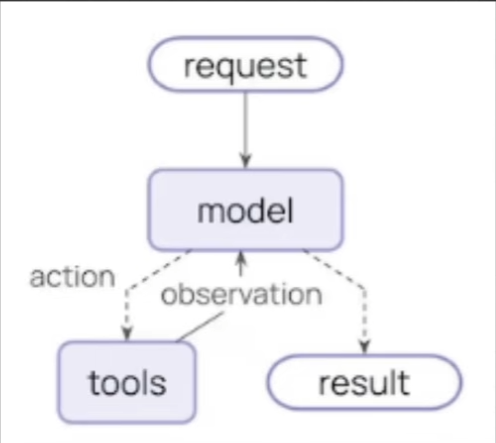

Agent With MiddleWare<br>
MiddleWare exposes `hooks`: which means trigger points, where things can be added like before model or before agent.<br>

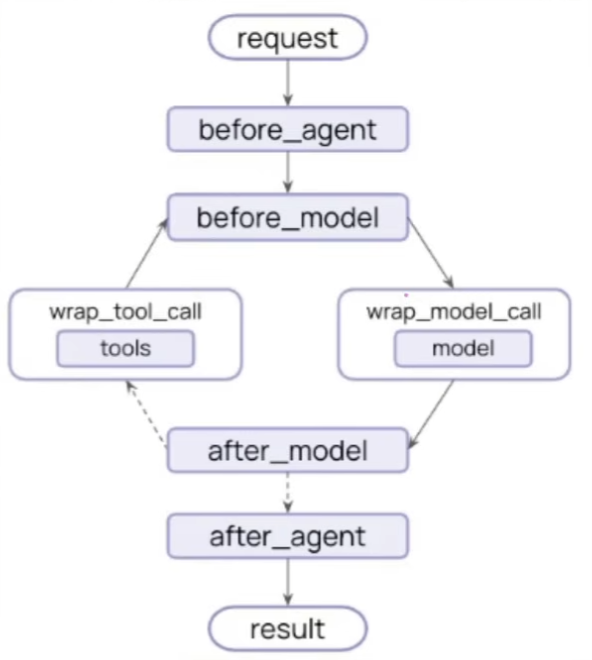

## Summarization MiddleWare 

Automatically summarize conversation history when approaching token limits, preserving the recent messages while compressing older context. Summarization is useful in the following scenario:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

In [59]:
# Built-In Summarization Middleware
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver # For storing conversation history in memory as checkpoints.
from langchain_core.messages import HumanMessage, SystemMessage

# Message based summarization
agent=create_agent(
    model="claude-sonnet-4-6",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="claude-sonnet-4-6",
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)
# Basically what's happening here is that after every 10 messages the summarization middleware will summarize the conversation 
# and keep the last 4 messages along with the summary. 
# This helps in keeping the conversation context manageable for the model while still retaining important information from the earlier messages.

In [60]:
# Run with thread id to uniquely identify the conversation thread and manage state across interactions.
config={"configurable":{"thread_id":"test-1"}}

In [61]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='f1db0e48-8308-4b5d-827a-76540a53f9df'), AIMessage(content='2 + 2 = **4**', additional_kwargs={}, response_metadata={'id': 'msg_018CBph9C9NnVw2yaBvMxeDE', 'model': 'claude-sonnet-4-6', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 14, 'output_tokens': 14, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'global'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019db758-9d9d-7db2-bdca-be828558e51a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 14, 'total_tokens': 28, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens

## Token Size Summarization Trigger

In [62]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""


agent=create_agent(
    model="claude-sonnet-4-6",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="claude-sonnet-4-6",
            trigger=("tokens",550),
            keep=("tokens",200),
        ),
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

In [63]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~284 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='9bbb71a3-cb6e-4cbc-a1d6-74f28cd540ee'), AIMessage(content=[{'text': "I'll search for hotels in Paris right away!", 'type': 'text'}, {'id': 'toolu_01B3JwjniMtwVQDVfWi4edeQ', 'input': {'city': 'Paris'}, 'name': 'search_hotels', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_016yVQ9y8JE69LYZpEM21nCh', 'model': 'claude-sonnet-4-6', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 566, 'output_tokens': 64, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'global'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019db759-f60a-7d91-a720-71c10e5c2466-0', tool_calls=[{'n

## Fraction (Based on Context size of LLM Model being used)

In [65]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:qwen/qwen3-32b",
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  # gpt-4o-mini context
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~67 tokens (0.0523%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='40a9437b-6926-4bcd-930a-919a69b1e321'), AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking for hotels in Paris. Let me check the tools available. There's a function called search_hotels that takes a city parameter. Since the user specified Paris, I need to call this function with the city set to Paris. I'll make sure the arguments are correctly formatted as JSON within the tool_call tags.\n", 'tool_calls': [{'id': '41eek5g7w', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 147, 'total_tokens': 240, 'completion_time': 0.140921744, 'completion_tokens_details': {'reasoning_tokens': 68}, 'prompt_time': 0.006848183, 'prompt_tokens_details': None, 'queue_time': 0.085351554, 'total_time': 0.147769927}, 'model_n

## Human In The Loop MiddleWare

Pause agent execution for human approval, editing, or rejecting of tool calls before they execute. Human-In-The-Loop is useful in the follownig scenarios:
- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [66]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [67]:
agent=create_agent(
    model="claude-sonnet-4-6",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
)

In [68]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [69]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='6b2490ac-1b5f-4a09-9789-d7633aab32af'),
  AIMessage(content=[{'id': 'toolu_01A1YQQRxrcPzeKcPhXFAam2', 'input': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'name': 'send_email_tool', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_01WwnkbQ7yNESwpMMYetmTBP', 'model': 'claude-sonnet-4-6', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 672, 'output_tokens': 97, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'global'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019db763-42f1-7380-b3ee-e1a3dfeb02

In [70]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command( # It executes the command that was generated by the model and paused by the middleware and resumes the execution based on the decision made by the human in the loop.
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The email has been successfully sent! Here's a summary of what was delivered:

- **Recipient:** john@test.com
- **Subject:** Hello
- **Body:** How are you?

Let me know if there's anything else you'd like to do!


In [71]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='6b2490ac-1b5f-4a09-9789-d7633aab32af'),
  AIMessage(content=[{'id': 'toolu_01A1YQQRxrcPzeKcPhXFAam2', 'input': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'name': 'send_email_tool', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_01WwnkbQ7yNESwpMMYetmTBP', 'model': 'claude-sonnet-4-6', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 672, 'output_tokens': 97, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'global'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019db763-42f1-7380-b3ee-e1a3dfeb02

**Rejecting**

In [72]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="claude-sonnet-4-6",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [73]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [74]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: It seems the email sending action was rejected and the email was **not sent**. This could be due to:

- A permission or authorization issue.
- The action was manually declined.

Would you like me to try again, or is there anything else I can help you with?


In [75]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='2d9e8100-4a7c-43b9-a7a0-566986839905'),
  AIMessage(content=[{'id': 'toolu_01HavRHdQcjQyGHzK1Vj1QVE', 'input': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'name': 'send_email_tool', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_01WHid3uwDuZE7j1BQiAL2fM', 'model': 'claude-sonnet-4-6', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 672, 'output_tokens': 97, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'global'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019db764-c71e-71d3-bcf7-938a54fff8

**Editing**

In [77]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="claude-sonnet-4-6",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [78]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [79]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='02ca51bb-4e12-4185-a09b-7e19caa2ace1'),
  AIMessage(content=[{'text': "I'll send that email right away!", 'type': 'text'}, {'id': 'toolu_01GPNrrPonYEava4WNMS8Sz3', 'input': {'recipient': 'wrong@email.com', 'subject': 'Test', 'body': 'Hello'}, 'name': 'send_email_tool', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_011z3ymcnqbodvABJcjtKqM2', 'model': 'claude-sonnet-4-6', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 669, 'output_tokens': 102, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'global'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropi

In [80]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: The email has been sent! Here's a summary of what was sent:
- **Recipient:** wrong@email.com
- **Subject:** Test
- **Body:** Hello

Let me know if there's anything else you need! 😊


In [81]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='02ca51bb-4e12-4185-a09b-7e19caa2ace1'),
  AIMessage(content=[{'text': "I'll send that email right away!", 'type': 'text'}, {'id': 'toolu_01GPNrrPonYEava4WNMS8Sz3', 'input': {'recipient': 'wrong@email.com', 'subject': 'Test', 'body': 'Hello'}, 'name': 'send_email_tool', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_011z3ymcnqbodvABJcjtKqM2', 'model': 'claude-sonnet-4-6', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 669, 'output_tokens': 102, 'server_tool_use': None, 'service_tier': 'standard', 'inference_geo': 'global'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropi